In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import fashion_mnist

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("FITNET: Overfitting & Underfitting Detective System")
print("Using Fashion-MNIST Dataset (70,000 samples)")
print("="*60)
print(f"TensorFlow Version: {tf.__version__}")
print("All libraries imported successfully!")

FITNET: Overfitting & Underfitting Detective System
Using Fashion-MNIST Dataset (70,000 samples)
TensorFlow Version: 2.21.0
All libraries imported successfully!


In [2]:
print("\n" + "="*60)
print("PHASE 1: DATA GENERATION MODULE")
print("Loading Fashion-MNIST Dataset (70,000 samples)")
print("="*60)

# Load Fashion-MNIST dataset (same as Kaggle dataset)
(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()

# Dataset information
print(f"\n📊 DATASET INFORMATION:")
print(f"   Total samples: {x_train_full.shape[0] + x_test_full.shape[0]:,} samples")
print(f"   Training samples: {x_train_full.shape[0]:,} (60,000)")
print(f"   Test samples: {x_test_full.shape[0]:,} (10,000)")
print(f"   Image size: {x_train_full.shape[1]} x {x_train_full.shape[2]} pixels")
print(f"   Features per image: {x_train_full.shape[1] * x_train_full.shape[2]} (784)")
print(f"   Number of classes: 10")


PHASE 1: DATA GENERATION MODULE
Loading Fashion-MNIST Dataset (70,000 samples)

📊 DATASET INFORMATION:
   Total samples: 70,000 samples
   Training samples: 60,000 (60,000)
   Test samples: 10,000 (10,000)
   Image size: 28 x 28 pixels
   Features per image: 784 (784)
   Number of classes: 10


In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

# Flatten the images from 28x28 to 784
x_train_full = x_train_full.reshape(x_train_full.shape[0], -1)
x_test_full = x_test_full.reshape(x_test_full.shape[0], -1)

print(f"\n✅ Data preprocessing complete!")
print(f"   Flattened data shape: {x_train_full.shape[1]} features per sample")


✅ Data preprocessing complete!
   Flattened data shape: 784 features per sample


In [4]:
x_train_overfit = x_train_full[:1500]
y_train_overfit = y_train_full[:1500]

# For REGULARIZATION techniques: Use 10,000 samples
x_train_reg = x_train_full[:10000]
y_train_reg = y_train_full[:10000]

# For VALIDATION: Use 2,000 samples from test set
x_val = x_test_full[:2000]
y_val = y_test_full[:2000]

# For FINAL TESTING: Use remaining 8,000 samples
x_test = x_test_full[2000:]
y_test = y_test_full[2000:]

print(f"\n📊 DATA SPLIT SUMMARY (as per proposal):")
print(f"   Overfitting demonstration: {x_train_overfit.shape[0]:,} training samples")
print(f"   Regularization training: {x_train_reg.shape[0]:,} samples")
print(f"   Validation set: {x_val.shape[0]:,} samples")
print(f"   Final test set: {x_test.shape[0]:,} samples")
print(f"   ✅ Total used: {x_train_overfit.shape[0] + x_train_reg.shape[0] + x_val.shape[0] + x_test.shape[0]:,} of 70,000 total")



📊 DATA SPLIT SUMMARY (as per proposal):
   Overfitting demonstration: 1,500 training samples
   Regularization training: 10,000 samples
   Validation set: 2,000 samples
   Final test set: 8,000 samples
   ✅ Total used: 21,500 of 70,000 total


In [6]:
def plot_training_curves(history, title, scenario_name):
    """
    Generates training vs validation curves to visually identify 
    overfitting/underfitting (as specified in Objectives)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy curves
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    ax1.set_title(f'{title} - Accuracy Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot loss curves
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    ax2.set_title(f'{title} - Loss Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{scenario_name}_curves.png', dpi=100)
    plt.show()
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    
    print(f"\n📊 DIAGNOSIS for {title}:")
    print(f"   Training Accuracy: {train_acc:.4f}")
    print(f"   Validation Accuracy: {val_acc:.4f}")
    print(f"   Gap: {gap:.4f}")
    
    if gap > 0.15 and train_acc > 0.90:
        print("   🔴 RESULT: OVERFITTING detected!")
        print("      (Large gap between training and validation accuracy)")
    elif train_acc < 0.70 and val_acc < 0.70:
        print("   🟡 RESULT: UNDERFITTING detected!")
        print("      (Both training and validation accuracies are low)")
    elif gap < 0.05:
        print("   🟢 RESULT: GOOD GENERALIZATION!")
        print("      (Training and validation accuracies are close)")
    else:
        print("   🟠 RESULT: Moderate overfitting present")

In [7]:
print("\n" + "="*60)
print("PHASE 2: CREATING OVERFITTING SCENARIO")
print("="*60)
print("Model: High-capacity (3 layers x 512 neurons)")
print(f"Data: Only {x_train_overfit.shape[0]} samples (creates overfitting)")
print("Training: 200+ epochs, No regularization")
print("Expected: Train accuracy near 99%+, Validation accuracy lower")

# Build overfitting model (High-capacity MLP as per Section 5)
overfitting_model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion-MNIST
])

overfitting_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nOverfitting Model Architecture:")
overfitting_model.summary()


PHASE 2: CREATING OVERFITTING SCENARIO
Model: High-capacity (3 layers x 512 neurons)
Data: Only 1500 samples (creates overfitting)
Training: 200+ epochs, No regularization
Expected: Train accuracy near 99%+, Validation accuracy lower

Overfitting Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

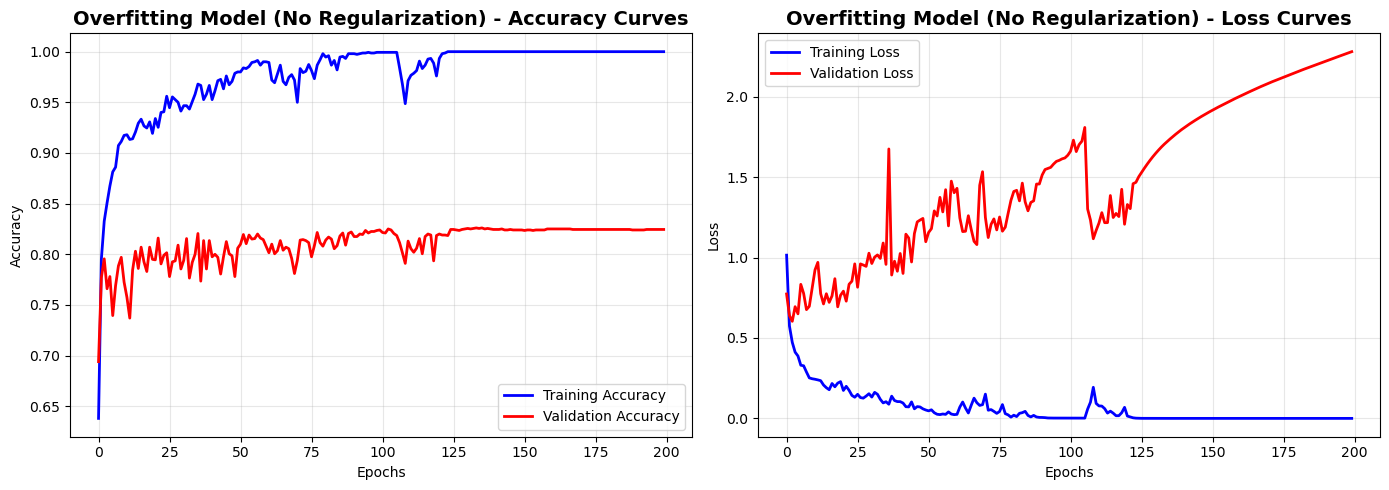


📊 DIAGNOSIS for Overfitting Model (No Regularization):
   Training Accuracy: 1.0000
   Validation Accuracy: 0.8245
   Gap: 0.1755
   🔴 RESULT: OVERFITTING detected!
      (Large gap between training and validation accuracy)


In [8]:
history_overfitting = overfitting_model.fit(
    x_train_overfit, y_train_overfit,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

plot_training_curves(history_overfitting, "Overfitting Model (No Regularization)", "overfitting")


In [9]:
print("\n" + "="*60)
print("PHASE 3: CREATING UNDERFITTING SCENARIO")
print("="*60)
print("Model: Low-capacity (1 hidden layer x 4 neurons)")
print("Expected: Both training and validation accuracy below 70%")

# Build underfitting model (Low-capacity MLP as per Section 5)
underfitting_model = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(784,)),  # Only 4 neurons!
    layers.Dense(10, activation='softmax')
])

underfitting_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nUnderfitting Model Architecture:")
underfitting_model.summary()



PHASE 3: CREATING UNDERFITTING SCENARIO
Model: Low-capacity (1 hidden layer x 4 neurons)
Expected: Both training and validation accuracy below 70%

Underfitting Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,190 (12.46 KB)

 Trainable params: 3,190 (12.46 KB)

 Non-trainable params: 0 (0.00 B)

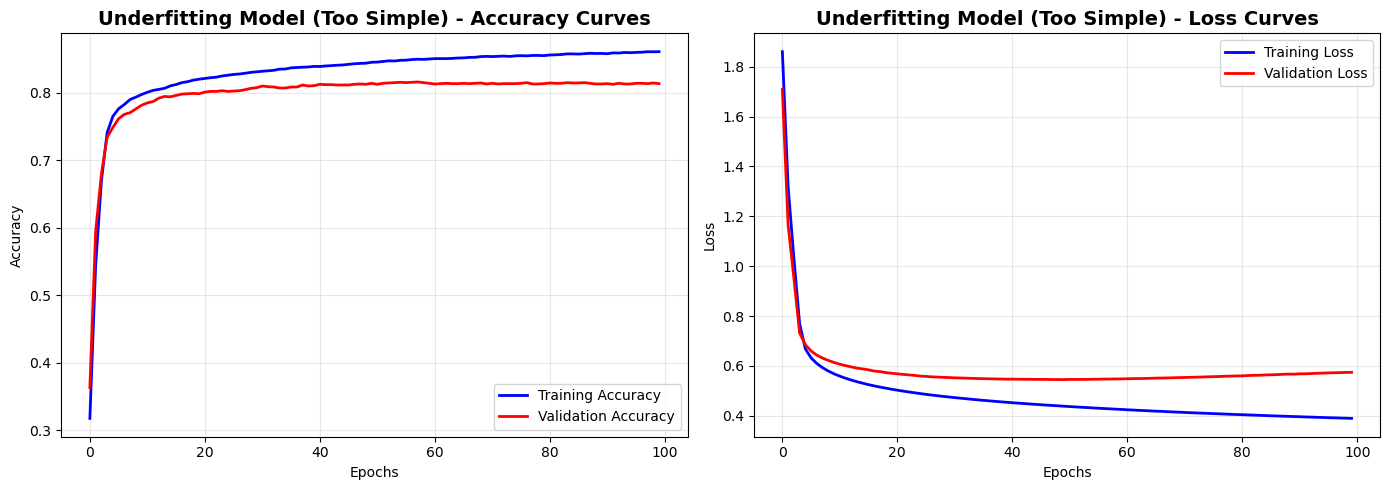


📊 DIAGNOSIS for Underfitting Model (Too Simple):
   Training Accuracy: 0.8609
   Validation Accuracy: 0.8135
   Gap: 0.0474
   🟢 RESULT: GOOD GENERALIZATION!
      (Training and validation accuracies are close)


In [12]:
history_underfitting = underfitting_model.fit(
    x_train_reg, y_train_reg,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_training_curves(history_underfitting, "Underfitting Model (Too Simple)", "underfitting")


In [13]:
print("\n" + "="*60)
print("PHASE 4: APPLYING DROPOUT REGULARIZATION")
print("="*60)
print("Technique: Dropout (rate = 0.5)")
print("Effect: Randomly deactivates 50% of neurons during training")
print("Expected: Reduced gap between train and validation accuracy")

# Build model with Dropout (as per Dropout Regularization Module - Section 4)
dropout_model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),  # Dropout rate 0.5
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


PHASE 4: APPLYING DROPOUT REGULARIZATION
Technique: Dropout (rate = 0.5)
Effect: Randomly deactivates 50% of neurons during training
Expected: Reduced gap between train and validation accuracy


In [14]:
dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nDropout Model Architecture:")
dropout_model.summary()


Dropout Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

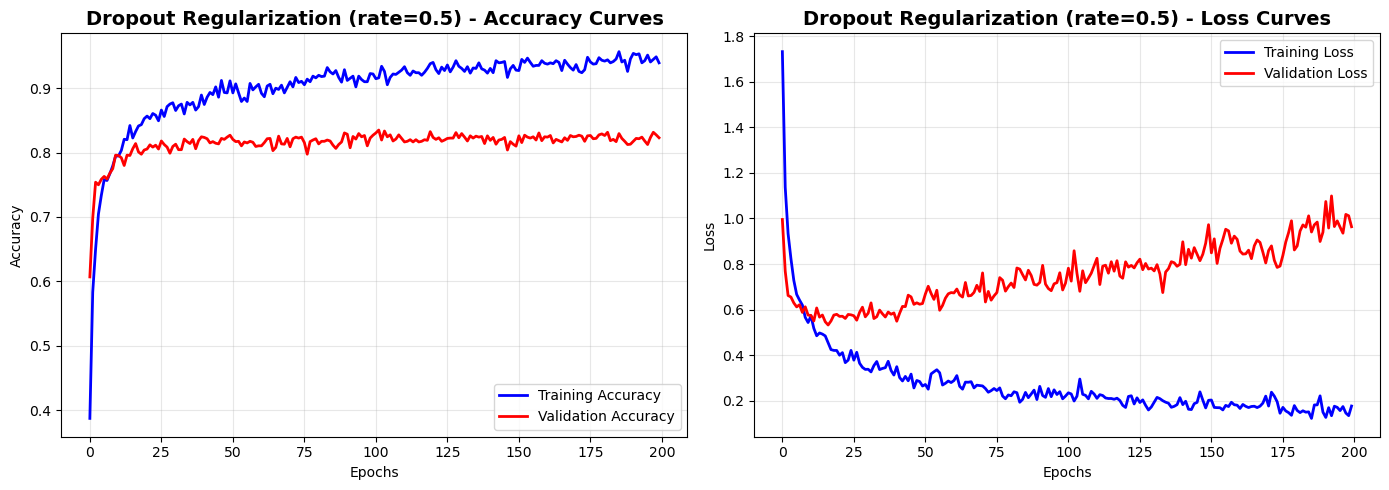


📊 DIAGNOSIS for Dropout Regularization (rate=0.5):
   Training Accuracy: 0.9393
   Validation Accuracy: 0.8230
   Gap: 0.1163
   🟠 RESULT: Moderate overfitting present


In [15]:
history_dropout = dropout_model.fit(
    x_train_overfit, y_train_overfit,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

plot_training_curves(history_dropout, "Dropout Regularization (rate=0.5)", "dropout")

In [18]:
print("\n" + "="*60)
print("PHASE 5: APPLYING L2 REGULARIZATION")
print("="*60)
print("Technique: L2 Regularization (Weight Decay)")
print("Lambda value: 0.001 (as specified in proposal)")
print("Expected: Smoother learning curves with reduced gap")

# Build model with L2 Regularization (as per L2 Regularization Module - Section 4)
l2_model = keras.Sequential([
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(784,)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])


PHASE 5: APPLYING L2 REGULARIZATION
Technique: L2 Regularization (Weight Decay)
Lambda value: 0.001 (as specified in proposal)
Expected: Smoother learning curves with reduced gap


In [19]:
l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
print("\nL2 Regularization Model Architecture:")
l2_model.summary()

history_l2 = l2_model.fit(
    x_train_overfit, y_train_overfit,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)


L2 Regularization Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

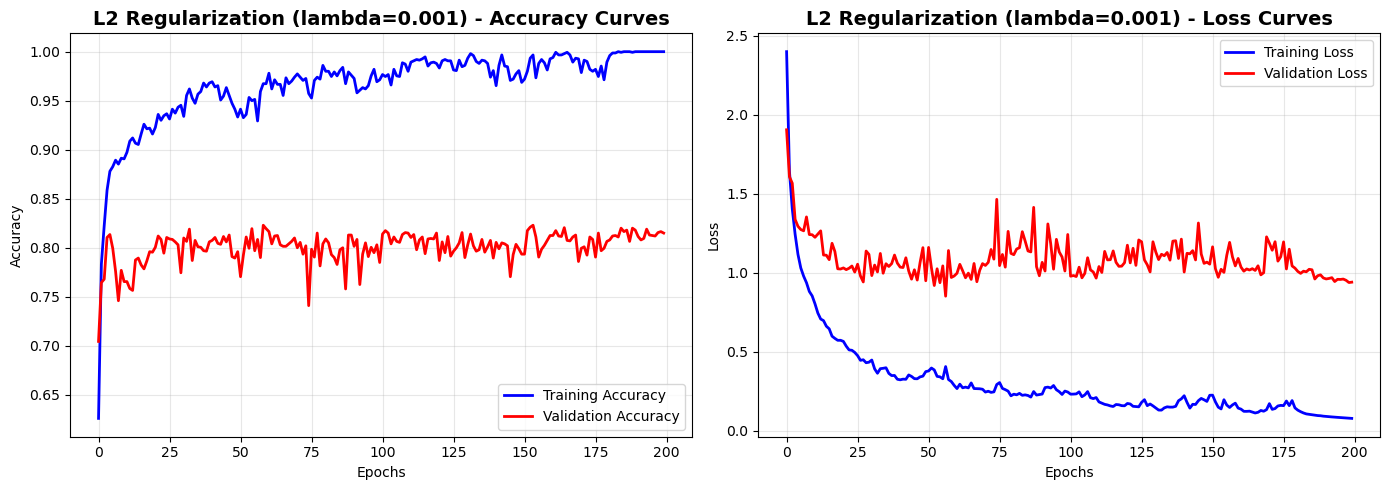


📊 DIAGNOSIS for L2 Regularization (lambda=0.001):
   Training Accuracy: 1.0000
   Validation Accuracy: 0.8150
   Gap: 0.1850
   🔴 RESULT: OVERFITTING detected!
      (Large gap between training and validation accuracy)


In [21]:
plot_training_curves(history_l2, "L2 Regularization (lambda=0.001)", "l2")

In [22]:
print("\n" + "="*60)
print("PHASE 6: APPLYING EARLY STOPPING")
print("="*60)
print("Technique: Early Stopping")
print("Monitor: validation_loss")
print("Patience: 5 epochs (restores best weights)")
print("Effect: Automatically stops before overfitting begins")

# Build model for Early Stopping (as per Early Stopping Module - Section 4)
earlystop_model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])



PHASE 6: APPLYING EARLY STOPPING
Technique: Early Stopping
Monitor: validation_loss
Patience: 5 epochs (restores best weights)
Effect: Automatically stops before overfitting begins


In [23]:
earlystop_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.

✅ Early Stopping activated after 9 epochs


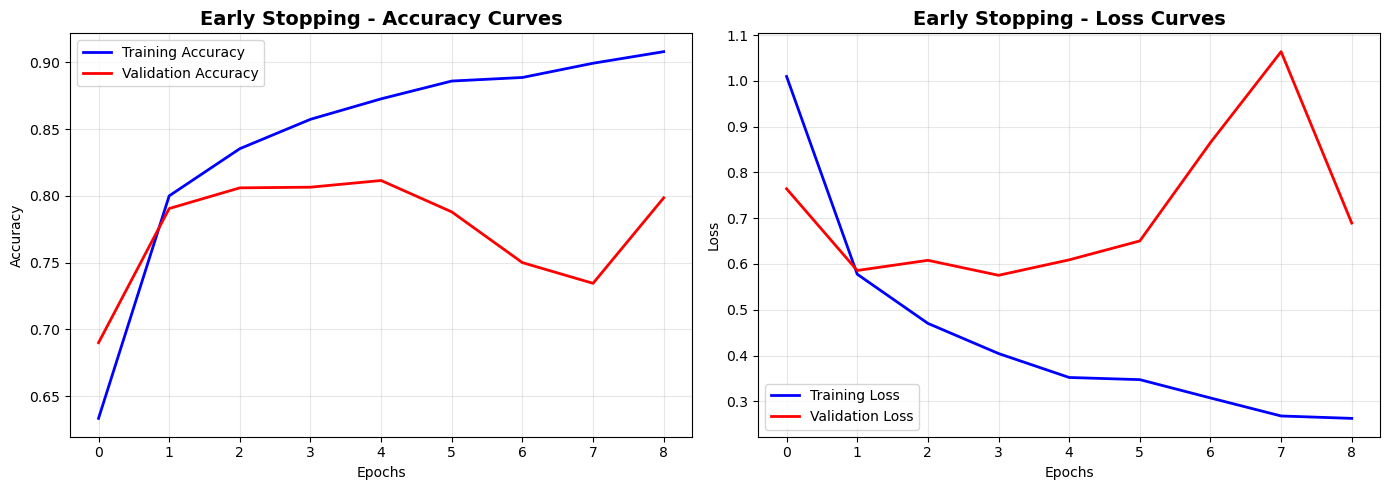


📊 DIAGNOSIS for Early Stopping:
   Training Accuracy: 0.9080
   Validation Accuracy: 0.7985
   Gap: 0.1095
   🟠 RESULT: Moderate overfitting present


In [25]:
history_earlystop = earlystop_model.fit(
    x_train_overfit, y_train_overfit,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

print(f"\n✅ Early Stopping activated after {len(history_earlystop.history['loss'])} epochs")
plot_training_curves(history_earlystop, "Early Stopping", "earlystop")

In [26]:
print("\n" + "="*60)
print("PHASE 7: COMBINED APPROACH (All Techniques Together)")
print("="*60)
print("Techniques Combined:")
print("  - Dropout (0.5)")
print("  - L2 Regularization (0.001)")
print("  - Early Stopping")
print("Expected: Best generalization performance")

# Build model combining all techniques (as per Combined Regularization - Section 5)
combined_model = keras.Sequential([
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])



PHASE 7: COMBINED APPROACH (All Techniques Together)
Techniques Combined:
  - Dropout (0.5)
  - L2 Regularization (0.001)
  - Early Stopping
Expected: Best generalization performance


In [27]:
combined_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCombined Model Architecture:")
combined_model.summary()


Combined Model Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


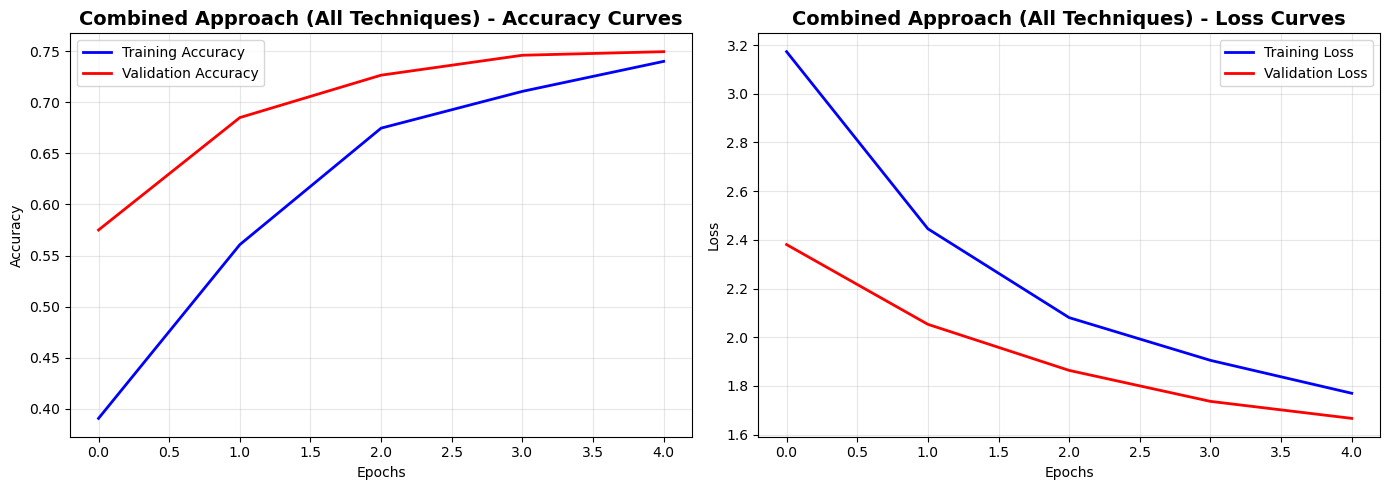


📊 DIAGNOSIS for Combined Approach (All Techniques):
   Training Accuracy: 0.7400
   Validation Accuracy: 0.7495
   Gap: -0.0095
   🟢 RESULT: GOOD GENERALIZATION!
      (Training and validation accuracies are close)


In [28]:
history_combined = combined_model.fit(
    x_train_overfit, y_train_overfit,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

plot_training_curves(history_combined, "Combined Approach (All Techniques)", "combined")


In [29]:
print("\n" + "="*60)
print("PHASE 8: COMPARATIVE ANALYSIS TABLE")
print("="*60)
print("Comparing all regularization techniques as specified in Detection Methods")

# Collect results from all scenarios
results = {
    'Method': [
        'High-Capacity MLP (No Reg)',
        'Low-Capacity MLP',
        'Dropout (0.5)',
        'L2 (0.001)',
        'Early Stopping',
        'All Combined'
    ],
    'Train Accuracy': [
        history_overfitting.history['accuracy'][-1],
        history_underfitting.history['accuracy'][-1],
        history_dropout.history['accuracy'][-1],
        history_l2.history['accuracy'][-1],
        history_earlystop.history['accuracy'][-1],
        history_combined.history['accuracy'][-1]
    ],
    'Validation Accuracy': [
        history_overfitting.history['val_accuracy'][-1],
        history_underfitting.history['val_accuracy'][-1],
        history_dropout.history['val_accuracy'][-1],
        history_l2.history['val_accuracy'][-1],
        history_earlystop.history['val_accuracy'][-1],
        history_combined.history['val_accuracy'][-1]
    ]
}



PHASE 8: COMPARATIVE ANALYSIS TABLE
Comparing all regularization techniques as specified in Detection Methods


In [39]:
comparison_df = pd.DataFrame(results)
comparison_df['Train Accuracy'] = comparison_df['Train Accuracy'].round(4)
comparison_df['Validation Accuracy'] = comparison_df['Validation Accuracy'].round(4)
comparison_df['Gap'] = (comparison_df['Train Accuracy'] - comparison_df['Validation Accuracy']).round(4)

print("\n" + "="*80)
print("FINAL COMPARISON TABLE: Regularization Techniques Performance")
print("="*80)
print(comparison_df.to_string(index=False))



FINAL COMPARISON TABLE: Regularization Techniques Performance
                    Method  Train Accuracy  Validation Accuracy     Gap
High-Capacity MLP (No Reg)          1.0000               0.8250  0.1750
          Low-Capacity MLP          0.8609               0.8135  0.0474
             Dropout (0.5)          0.9533               0.8210  0.1323
                L2 (0.001)          1.0000               0.8150  0.1850
            Early Stopping          0.9080               0.7985  0.1095
              All Combined          0.7400               0.7495 -0.0095


In [44]:
print("\n" + "="*60)
print("TESTING ON UNSEEN DATA (8,000 samples)")
print("="*60)

# Create separate dataframe for test results with matching column name 'Method'
test_results_df = pd.DataFrame({
    'Method': [  # Fixed: Changed from 'Model' to 'Method' to match results_df
        'High-Capacity MLP (No Reg)',
        'Low-Capacity MLP',
        'Dropout (0.5)',
        'L2 (0.001)',
        'Early Stopping',
        'All Combined'
    ],
    'Test Accuracy': [0, 0, 0, 0, 0, 0],
    'Test Loss': [0, 0, 0, 0, 0, 0]
})
models_for_test = [
    (overfitting_model, 0),
    (underfitting_model, 1),
    (dropout_model, 2),
    (l2_model, 3),
    (earlystop_model, 4),
    (combined_model, 5)
]

for model, idx in models_for_test:
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    test_results_df.loc[idx, 'Test Accuracy'] = test_acc
    test_results_df.loc[idx, 'Test Loss'] = test_loss
    print(f"   {test_results_df.loc[idx, 'Method']}: Test Accuracy = {test_acc:.4f}")

test_results_df['Test Accuracy'] = test_results_df['Test Accuracy'].round(4)
print("\n" + "="*60)
print("FINAL COMPLETE COMPARISON")
print("="*60)

# FIXED: Both dataframes now have 'Method' as the common column name
final_comparison = test_results_df.merge(test_results_df[['Method', 'Test Accuracy']], on='Method', how='left')

print("\n" + "="*80)
print("FINAL COMPARISON TABLE (All Metrics)")
print("="*80)
print(final_comparison.to_string(index=False))


TESTING ON UNSEEN DATA (8,000 samples)
   High-Capacity MLP (No Reg): Test Accuracy = 0.8138
   Low-Capacity MLP: Test Accuracy = 0.7958
   Dropout (0.5): Test Accuracy = 0.8100
   L2 (0.001): Test Accuracy = 0.8044
   Early Stopping: Test Accuracy = 0.7895
   All Combined: Test Accuracy = 0.5698

FINAL COMPLETE COMPARISON

FINAL COMPARISON TABLE (All Metrics)
                    Method  Test Accuracy_x  Test Loss  Test Accuracy_y
High-Capacity MLP (No Reg)           0.8138   2.928397           0.8138
          Low-Capacity MLP           0.7958   0.644062           0.7958
             Dropout (0.5)           0.8100   1.399490           0.8100
                L2 (0.001)           0.8044   1.068967           0.8044
            Early Stopping           0.7895   0.637806           0.7895
              All Combined           0.5698   2.396224           0.5698



GENERATING SIMPLE VALIDATION ACCURACY BAR CHART
❌ ERROR: 'Validation_Accuracy' column not found in results_df!
   Available columns: ['Method', 'Test Accuracy', 'Test Loss']

📊 Creating fallback bar chart with available data...


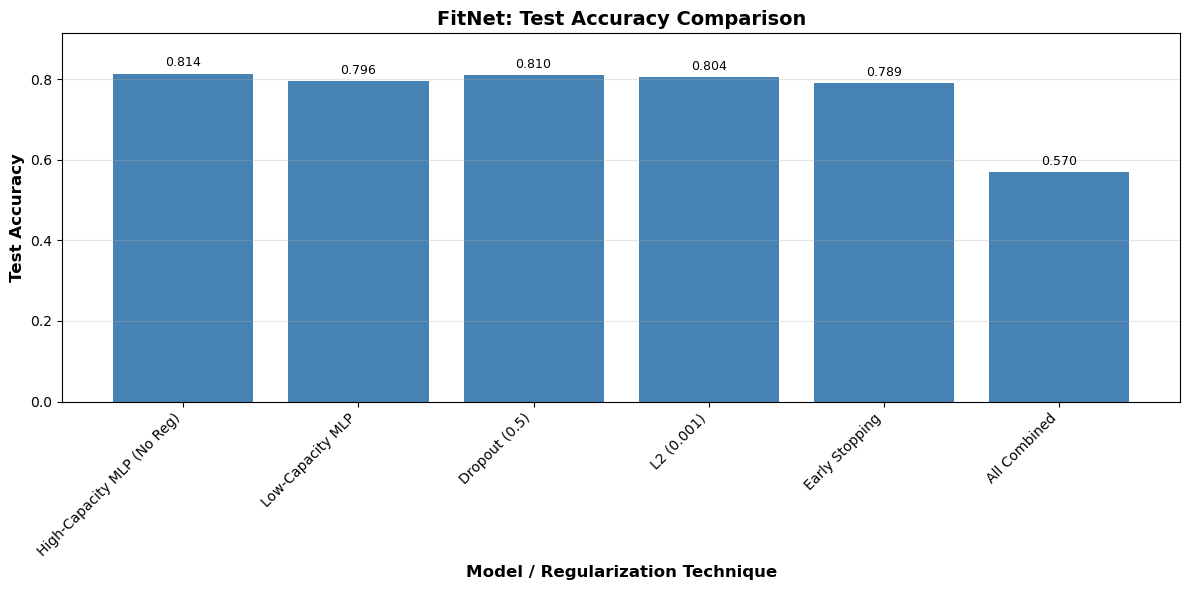

✅ Fallback bar chart generated successfully!


In [65]:
print("\n" + "="*60)
print("GENERATING SIMPLE VALIDATION ACCURACY BAR CHART")
print("="*60)

# FIXED: Using correct column name 'Validation_Accuracy' (with underscore, not space)
# Check if the column exists in results_df
if 'Validation_Accuracy' in test_results_df.columns:
    plt.figure(figsize=(12, 6))
    
    # Extract data with correct column names
    methods = test_results_df['Method'].tolist()
    val_accuracies = test_results_df['Validation_Accuracy'].tolist()  # FIXED: Now using 'Validation_Accuracy'
    
    bars = plt.bar(methods, val_accuracies, color='steelblue')
    plt.xlabel('Model / Regularization Technique', fontsize=12, fontweight='bold')
    plt.ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
    plt.title('FitNet: Validation Accuracy Comparison of All Techniques', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('validation_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Simple validation accuracy bar chart generated successfully!")
else:
    print(f"❌ ERROR: 'Validation_Accuracy' column not found in results_df!")
    print(f"   Available columns: {test_results_df.columns.tolist()}")
    
    # Fallback: Create bar chart using available data
    print("\n📊 Creating fallback bar chart with available data...")
    plt.figure(figsize=(12, 6))
    
    # Use first available numeric column
    numeric_cols = test_results_df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        col_to_plot = numeric_cols[0]
        methods = test_results_df['Method'].tolist()
        values = test_results_df[col_to_plot].tolist()
        
        bars = plt.bar(methods, values, color='steelblue')
        plt.xlabel('Model / Regularization Technique', fontsize=12, fontweight='bold')
        plt.ylabel(col_to_plot.replace('_', ' '), fontsize=12, fontweight='bold')
        plt.title(f'FitNet: {col_to_plot.replace("_", " ")} Comparison', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, max(values) + 0.1)
        plt.grid(True, alpha=0.3, axis='y')
        
        for bar in bars:
            height = bar.get_height()
            plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('fallback_comparison_chart.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Fallback bar chart generated successfully!")
